In [36]:
from collections import Counter

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ReduceLROnPlateau

import numpy as np

tf.random.set_seed(42)

## Tâches

### Tâche 1 : Chargement et Exploration
1. Chargez le dataset MNIST depuis `keras.datasets.mnist`
2. Explorez les dimensions : shape des images et labels
3. Affichez 10 images avec leurs labels
4. Analysez la distribution des classes
5. Vérifiez les valeurs des pixels (0-255)

Attendus : Dataset compris, visualisations claires

In [37]:
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

print(f"Train features set shape: {X_train.shape}")
print(f"Train labels set shape: {y_train.shape}")
print(f"Test features set shape: {X_test.shape}")
print(f"Test labels set shape: {y_test.shape}")

Train features set shape: (60000, 28, 28)
Train labels set shape: (60000,)
Test features set shape: (10000, 28, 28)
Test labels set shape: (10000,)


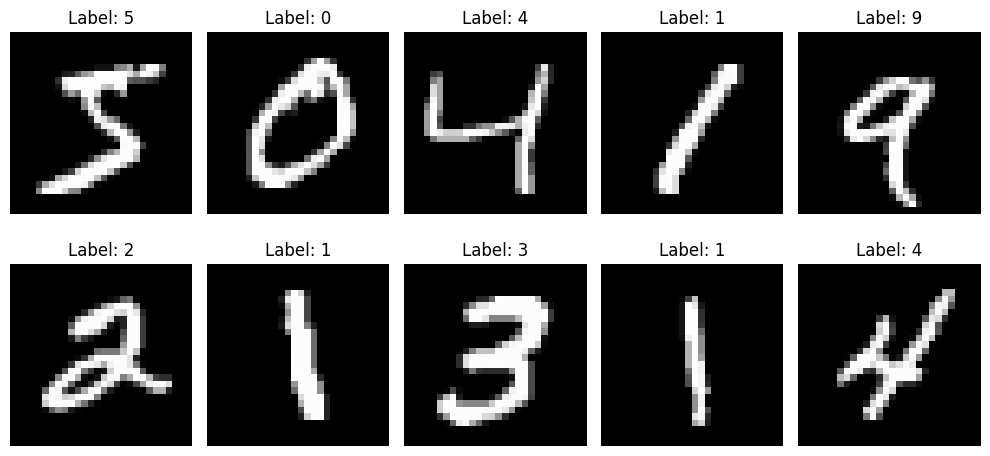

In [38]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

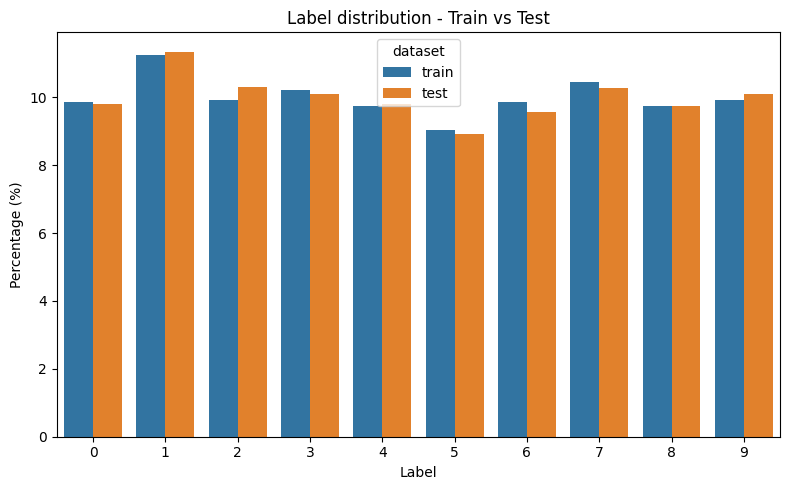

In [39]:
counter_train = Counter(y_train)
counter_test = Counter(y_test)

labels = sorted(set(y_train) | set(y_test))

df = pd.DataFrame(
    {
        "label": labels * 2,
        "percentage": (
            [counter_train.get(l, 0) / len(y_train) * 100 for l in labels]
            + [counter_test.get(l, 0) / len(y_test) * 100 for l in labels]
        ),
        "dataset": ["train"] * len(labels) + ["test"] * len(labels),
    }
)

plt.figure(figsize=(8, 5))

sns.barplot(data=df, x="label", y="percentage", hue="dataset")

plt.ylabel("Percentage (%)")
plt.xlabel("Label")
plt.title("Label distribution - Train vs Test")

plt.tight_layout()
plt.show()

* Peu de déséquilibre des classes constaté.
* Les jeux d'entraînement et de test ont une répartition semblable.

In [40]:
print(f"Pixels values range - Train set: [{X_train.min()}, {X_train.max()}]")
print(f"Pixels values range - Test set: [{X_test.min()}, {X_test.max()}]")

Pixels values range - Train set: [0, 255]
Pixels values range - Test set: [0, 255]


### Tâche 2 : Préparation des Données
1. Normalisez les pixels dans [0, 1]
2. Aplatissez les images 28x28 en vecteurs 784D
3. Convertissez les labels en one-hot encoding
4. Divisez en train/val/test (60k / 10k test)
5. Vérifiez les dimensions finales

Attendus : Données normalisées et formatées correctement

In [41]:
# Normalization: Divide pixels values by 255
X_train_norm = X_train.astype("float32") / 255.0
X_test_norm = X_test.astype("float32") / 255.0
print(
    f"Pixels values range - Train set normalize: [{X_train_norm.min()}, {X_train_norm.max()}]"
)
print(
    f"Pixels values range - Test set normalize: [{X_test_norm.min()}, {X_test_norm.max()}]"
)

# Flat: (n, 28, 28) -> (n, 784)
_, w, h = X_train_norm.shape
X_train_flat = X_train_norm.reshape(-1, w * h)
X_test_flat = X_test_norm.reshape(-1, w * h)
print(f"\nTrain set flat shape: {X_train_flat.shape}")
print(f"Test set flat shape: {X_test_flat.shape}")

# Encode labels: 9 -> [0, 0, 0, 0, 0, 0, 0, 0, 1, 0]
y_train_onehot = keras.utils.to_categorical(y_train, num_classes=10)
y_test_onehot = keras.utils.to_categorical(y_test, num_classes=10)
print("\nLabels encoded:")
for label in np.unique(y_train):
    idx = np.where(y_train == label)[0][0]
    print(f"{label} ---> {y_train_onehot[idx]}")

Pixels values range - Train set normalize: [0.0, 1.0]
Pixels values range - Test set normalize: [0.0, 1.0]

Train set flat shape: (60000, 784)
Test set flat shape: (10000, 784)

Labels encoded:
0 ---> [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
1 ---> [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
2 ---> [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
3 ---> [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
4 ---> [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
5 ---> [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
6 ---> [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
7 ---> [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
8 ---> [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]
9 ---> [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


### Tâche 3 : Architecture MLP
1. Construisez un modèle Sequential avec Keras :
   - Input : 784 unités
   - Hidden 1 : 128 unités, activation ReLU
   - Hidden 2 : 64 unités, activation ReLU
   - Hidden 3 : 32 unités, activation ReLU
   - Output : 10 unités, activation Softmax
2. Compilez avec :
   - Optimizer : Adam (learning_rate=0.001)
   - Loss : categorical_crossentropy
   - Metrics : accuracy
3. Affichez le résumé du modèle

Attendus : Architecture définie et compilée correctement

In [42]:
def create_model():
    model = keras.Sequential(
        [
            layers.Dense(128, activation="relu", input_shape=(w * h,), name="hidden_1"),
            layers.Dense(64, activation="relu", name="hidden_2"),
            layers.Dense(32, activation="relu", name="hidden_3"),
            layers.Dense(10, activation="softmax", name="output"),
        ],
        name="MLP_MNIST",
    )

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


tf.keras.backend.clear_session()
model = create_model()
model.summary()

c:\Users\Administrateur\Documents\M2i_CDSD_TDTP\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,146 (434.16 KB)

 Trainable params: 111,146 (434.16 KB)

 Non-trainable params: 0 (0.00 B)

### Tâche 4 : Entraînement
1. Entraînez le modèle :
   - Batch size : 32
   - Epochs : 20
   - Validation split : 0.2
2. Utilisez les callbacks :
   - EarlyStopping (monitor='val_loss', patience=3)
   - ReduceLROnPlateau (si possible)
3. Sauvegardez l'historique d'entraînement

Attendus : Modèle entraîné sans erreurs, historique sauvegardé

In [43]:
def create_reduce_lr():
    return ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1,
    )


history = model.fit(
    X_train_flat,
    y_train_onehot,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[create_reduce_lr()],
    verbose=1,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9166 - loss: 0.2868 - val_accuracy: 0.9588 - val_loss: 0.1373 - learning_rate: 0.0010
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9649 - loss: 0.1167 - val_accuracy: 0.9680 - val_loss: 0.1148 - learning_rate: 0.0010
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9764 - loss: 0.0785 - val_accuracy: 0.9709 - val_loss: 0.1049 - learning_rate: 0.0010
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9824 - loss: 0.0580 - val_accuracy: 0.9690 - val_loss: 0.1195 - learning_rate: 0.0010
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9864 - loss: 0.0434 - val_accuracy: 0.9714 - val_loss: 0.1167 - learning_rate: 0.0010
Epoch 6/20
1485/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9861 - loss: 0.0421
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9874 - lo

### Tâche 5 : Évaluation sur le Test Set
1. Évaluez sur le test set :
   - Accuracy
   - Loss
2. Prédisez sur les 10 premiers images de test
3. Comparez prédictions vs labels réels
4. Affichez 5 exemples (image + prédiction + vraie label)

Attendus : Évaluation complète, visualisations

In [44]:
test_loss, test_accuracy = model.evaluate(X_test_flat, y_test_onehot, verbose=1)

print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - accuracy: 0.9813 - loss: 0.1054
Test loss: 0.10535725206136703
Test accuracy: 0.9812999963760376


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 622us/step


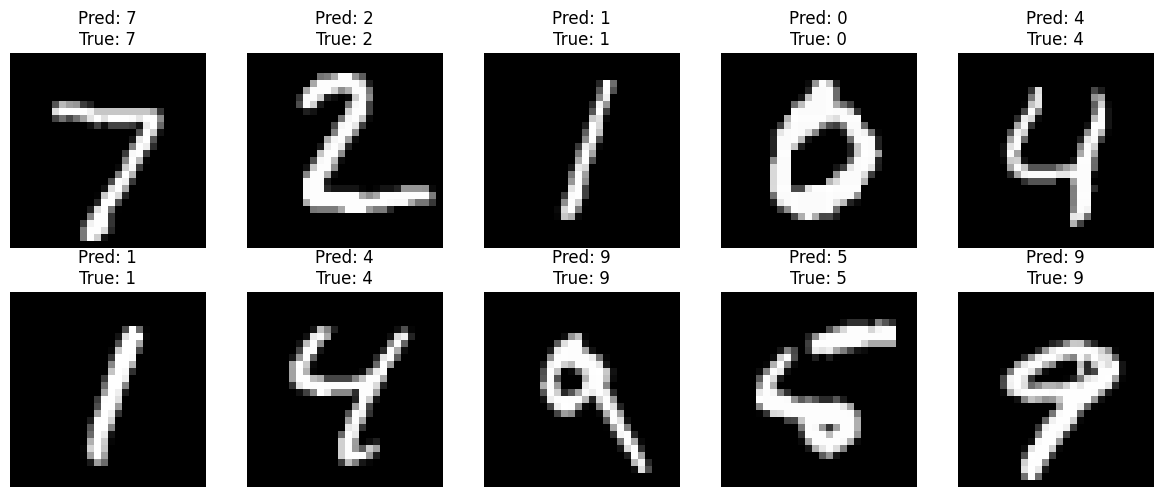

In [45]:
predictions = model.predict(X_test_flat)
predicted_classes = np.argmax(predictions, axis=1)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(f"Pred: {predicted_classes[i]}\nTrue: {y_test[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

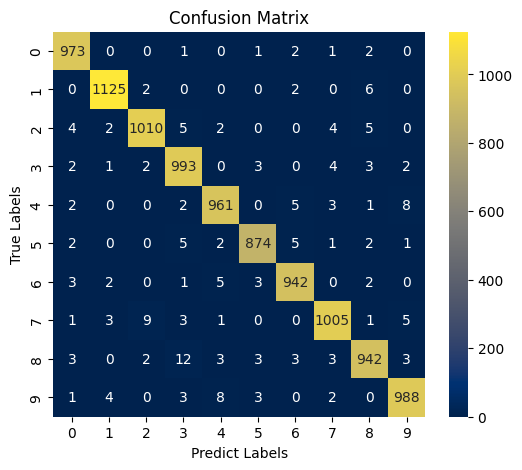

In [46]:
cm = tf.math.confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="cividis")
plt.xlabel("Predict Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

### Tâche 6 : Analyse des Courbes d'Apprentissage
1. Tracez la courbe train loss vs validation loss
2. Tracez la courbe train accuracy vs validation accuracy
3. Analysez le comportement :
   - Y a-t-il overfitting?
   - Quand le modèle converge-t-il?
4. Identifiez les epochs optimaux

Attendus : Graphiques clairs, analyse critique

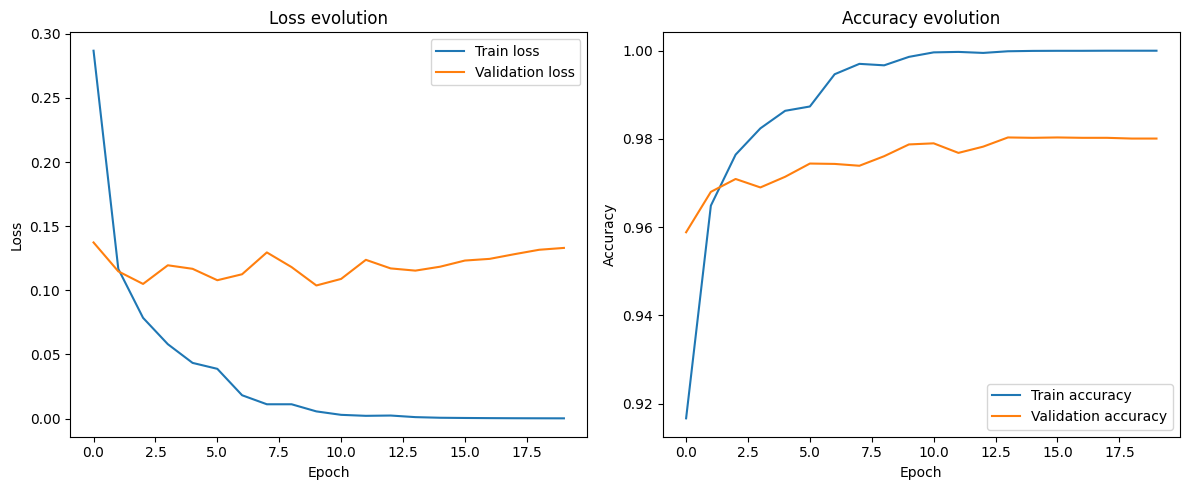

In [47]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(history.history["loss"], label="Train loss")
ax1.plot(history.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history.history["accuracy"], label="Train accuracy")
ax2.plot(history.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()

* Overfitting modéré

### Tâche 7 : Amélioration avec Régularisation
1. Ajoutez de la régularisation au modèle original :
   - Dropout(0.3) après chaque couche hidden
   - L2 regularization (kernel_regularizer='l2')
2. Comparez avec le modèle sans régularisation :
   - Même epoch count
   - Même données
3. Analysez l'impact sur l'overfitting

Attendus : Modèle amélioré, comparaison quantifiée

In [48]:
def create_model_regularized():
    model = keras.Sequential(
        [
            layers.Dense(
                128,
                activation="relu",
                input_shape=(w * h,),
                kernel_regularizer="l2",
                name="hidden_1",
            ),
            layers.Dropout(0.3),
            layers.Dense(
                64, activation="relu", kernel_regularizer="l2", name="hidden_2"
            ),
            layers.Dropout(0.3),
            layers.Dense(
                32, activation="relu", kernel_regularizer="l2", name="hidden_3"
            ),
            layers.Dropout(0.3),
            layers.Dense(
                10, activation="softmax", kernel_regularizer="l2", name="output"
            ),
        ],
        name="MLP_MNIST",
    )

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


tf.keras.backend.clear_session()
model_regularized = create_model_regularized()

history_regularized = model_regularized.fit(
    X_train_flat,
    y_train_onehot,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    callbacks=[create_reduce_lr()],
    verbose=1,
)

Epoch 1/20


c:\Users\Administrateur\Documents\M2i_CDSD_TDTP\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6964 - loss: 2.0381 - val_accuracy: 0.8950 - val_loss: 1.0415 - learning_rate: 0.0010
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8368 - loss: 1.1721 - val_accuracy: 0.9114 - val_loss: 0.9164 - learning_rate: 0.0010
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8515 - loss: 1.1012 - val_accuracy: 0.9147 - val_loss: 0.8819 - learning_rate: 0.0010
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8584 - loss: 1.0771 - val_accuracy: 0.9211 - val_loss: 0.8659 - learning_rate: 0.0010
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8619 - loss: 1.0588 - val_accuracy: 0.9193 - val_loss: 0.8634 - learning_rate: 0.0010
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8648 - loss: 1.0466 - val_accuracy: 0.9208 - val_loss: 0.8580 - learning_rate: 0.0010
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8659 - loss: 1.0440 - val_accurac

In [49]:
test_loss_regularized, test_accuracy_regularized = model_regularized.evaluate(
    X_test_flat, y_test_onehot, verbose=1
)

print(f"Test loss: {test_loss}")
print(f"Test accuracy : {test_accuracy}")
print(f"\nTest loss regularized: {test_loss_regularized}")
print(f"Test accuracy regularized: {test_accuracy_regularized}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - accuracy: 0.9205 - loss: 0.8519
Test loss: 0.10535725206136703
Test accuracy : 0.9812999963760376

Test loss regularized: 0.8518670201301575
Test accuracy regularized: 0.9204999804496765


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 626us/step


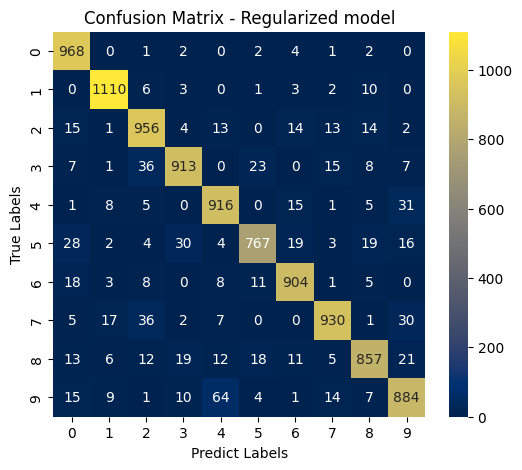

In [50]:
predictions_regularized = model_regularized.predict(X_test_flat)
predicted_classes_regularized = np.argmax(predictions_regularized, axis=1)
cm_regularized = tf.math.confusion_matrix(y_test, predicted_classes_regularized)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_regularized, annot=True, fmt="d", cmap="cividis")
plt.xlabel("Predict Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - Regularized model")
plt.show()

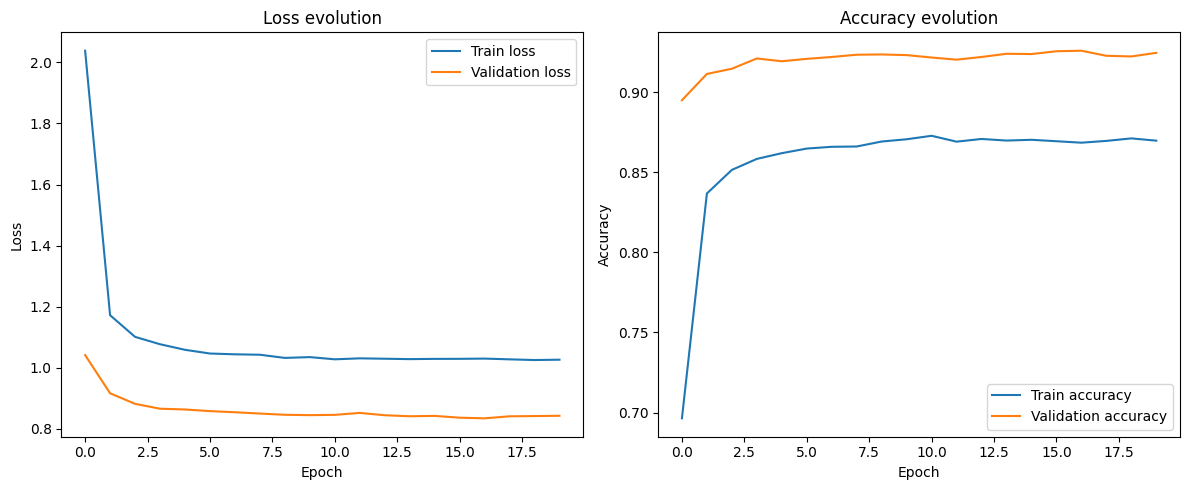

In [51]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(history_regularized.history["loss"], label="Train loss")
ax1.plot(history_regularized.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history_regularized.history["accuracy"], label="Train accuracy")
ax2.plot(history_regularized.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()

## Bonus (Optionnel)

- Testez d'autres architectures (couches plus larges/profondes)
- Implémentez une loss function personnalisée
- Utilisez optimiseurs alternatifs (SGD, RMSprop)
- Visualisez les poids appris (première couche)
- Explorez l'impact de la batch size

### Large Model

In [52]:
def create_model_large():
    model = keras.Sequential(
        [
            layers.Dense(
                1024, activation="relu", input_shape=(w * h,), name="hidden_1"
            ),
            layers.Dense(2048, activation="relu", name="hidden_2"),
            layers.Dense(1024, activation="relu", name="hidden_3"),
            layers.Dense(512, activation="relu", name="hidden_4"),
            layers.Dense(256, activation="relu", name="hidden_5"),
            layers.Dense(128, activation="relu", name="hidden_6"),
            layers.Dense(64, activation="relu", name="hidden_7"),
            layers.Dense(32, activation="relu", name="hidden_8"),
            layers.Dense(10, activation="softmax", name="output"),
        ],
        name="MLP_MNIST",
    )

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


tf.keras.backend.clear_session()
model_large = create_model_large()
model_large.summary()

c:\Users\Administrateur\Documents\M2i_CDSD_TDTP\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "MLP_MNIST"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 1024)           │       803,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 2048)           │     2,099,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_5 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_6 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_7 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_8 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,700,906 (21.75 MB)

 Trainable params: 5,700,906 (21.75 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history_large = model_large.fit(
    X_train_flat,
    y_train_onehot,
    epochs=10,
    batch_size=512,
    validation_split=0.2,
    callbacks=[create_reduce_lr()],
    verbose=1,
)

Epoch 1/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.8456 - loss: 0.4927 - val_accuracy: 0.9536 - val_loss: 0.1522 - learning_rate: 0.0010
Epoch 2/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9653 - loss: 0.1199 - val_accuracy: 0.9643 - val_loss: 0.1217 - learning_rate: 0.0010
Epoch 3/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.9768 - loss: 0.0785 - val_accuracy: 0.9590 - val_loss: 0.1530 - learning_rate: 0.0010
Epoch 4/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9830 - loss: 0.0564 - val_accuracy: 0.9722 - val_loss: 0.1039 - learning_rate: 0.0010
Epoch 5/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9882 - loss: 0.0402 - val_accuracy: 0.9696 - val_loss: 0.1249 - learning_rate: 0.0010
Epoch 6/10
94/94 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - accuracy: 0.9887 - loss: 0.0394 - val_accuracy: 0.9728 - val_loss: 0.1092 - learning_rate: 0.0010
Epoch 7/10
93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9911 - loss: 0.0293
Epoch 7: 

In [54]:
test_loss_large, test_accuracy_large = model_large.evaluate(
    X_test_flat, y_test_onehot, verbose=1
)

print(f"Test loss: {test_loss}")
print(f"Test accuracy : {test_accuracy}")
print(f"\nTest loss large: {test_loss_large}")
print(f"Test accuracy large: {test_accuracy_large}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9852 - loss: 0.0874
Test loss: 0.10535725206136703
Test accuracy : 0.9812999963760376

Test loss large: 0.08737516403198242
Test accuracy large: 0.9851999878883362


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


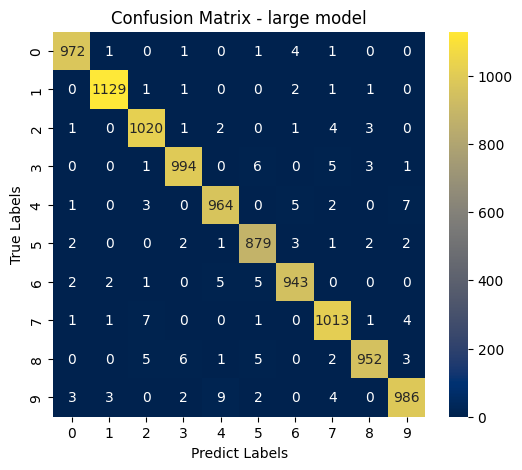

In [55]:
predictions_large = model_large.predict(X_test_flat)
predicted_classes_large = np.argmax(predictions_large, axis=1)
cm_large = tf.math.confusion_matrix(y_test, predicted_classes_large)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_large, annot=True, fmt="d", cmap="cividis")
plt.xlabel("Predict Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - large model")
plt.show()

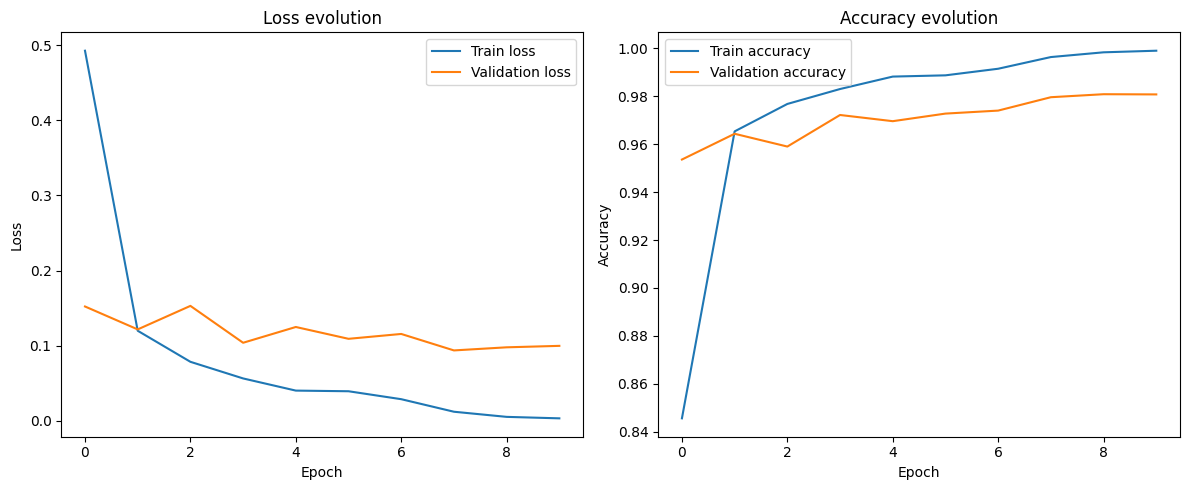

In [56]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(history_large.history["loss"], label="Train loss")
ax1.plot(history_large.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history_large.history["accuracy"], label="Train accuracy")
ax2.plot(history_large.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()

### SGD

In [57]:
def create_model_sgd():
    model = keras.Sequential(
        [
            layers.Dense(128, activation="relu", input_shape=(w * h,), name="hidden_1"),
            layers.Dense(64, activation="relu", name="hidden_2"),
            layers.Dense(32, activation="relu", name="hidden_3"),
            layers.Dense(10, activation="softmax", name="output"),
        ],
        name="MLP_MNIST",
    )

    model.compile(
        optimizer="sgd",
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


tf.keras.backend.clear_session()
model_sgd = create_model_sgd()

history_sgd = model_sgd.fit(
    X_train_flat,
    y_train_onehot,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[create_reduce_lr()],
    verbose=1,
)

Epoch 1/20


c:\Users\Administrateur\Documents\M2i_CDSD_TDTP\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7745 - loss: 0.8044 - val_accuracy: 0.9005 - val_loss: 0.3419 - learning_rate: 0.0100
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9109 - loss: 0.3110 - val_accuracy: 0.9253 - val_loss: 0.2565 - learning_rate: 0.0100
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9290 - loss: 0.2450 - val_accuracy: 0.9377 - val_loss: 0.2142 - learning_rate: 0.0100
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9400 - loss: 0.2053 - val_accuracy: 0.9462 - val_loss: 0.1876 - learning_rate: 0.0100
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9482 - loss: 0.1769 - val_accuracy: 0.9528 - val_loss: 0.1690 - learning_rate: 0.0100
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9546 - loss: 0.1551 - val_accuracy: 0.9556 - val_loss: 0.1555 - learning_rate: 0.0100
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9599 - loss: 0.1377

In [58]:
test_loss_sgd, test_accuracy_sgd = model_sgd.evaluate(
    X_test_flat, y_test_onehot, verbose=1
)

print(f"Test loss: {test_loss}")
print(f"Test accuracy : {test_accuracy}")
print(f"\nTest loss sgd: {test_loss_sgd}")
print(f"Test accuracy sgd: {test_accuracy_sgd}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 804us/step - accuracy: 0.9697 - loss: 0.0986
Test loss: 0.10535725206136703
Test accuracy : 0.9812999963760376

Test loss sgd: 0.09861220419406891
Test accuracy sgd: 0.9696999788284302


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 623us/step


Text(0.5, 1.0, 'Confusion Matrix - sgd model')

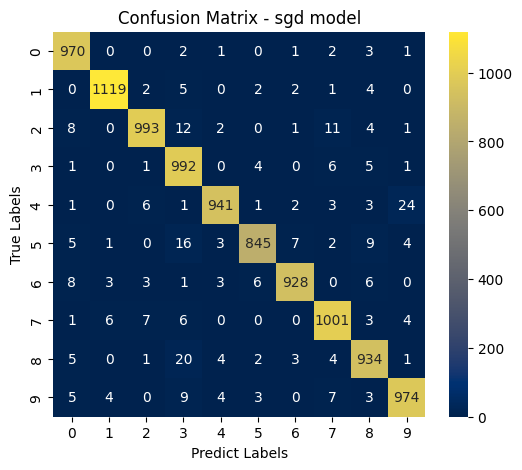

In [59]:
predictions_sgd = model_sgd.predict(X_test_flat)
predicted_classes_sgd = np.argmax(predictions_sgd, axis=1)
cm_sgd = tf.math.confusion_matrix(y_test, predicted_classes_sgd)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_sgd, annot=True, fmt="d", cmap="cividis")
plt.xlabel("Predict Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix - sgd model")

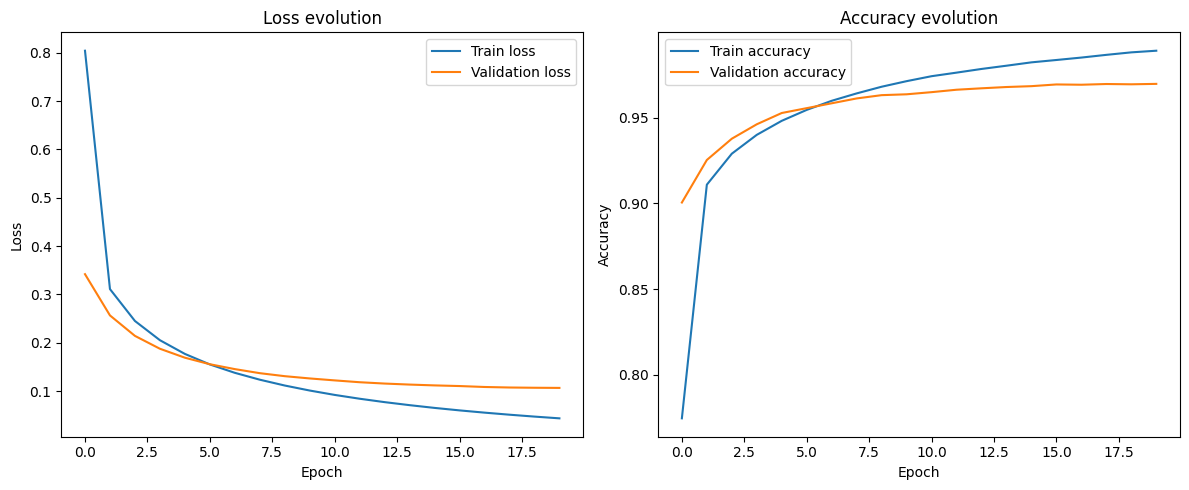

In [60]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Loss
ax1.plot(history_sgd.history["loss"], label="Train loss")
ax1.plot(history_sgd.history["val_loss"], label="Validation loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Loss evolution")
ax1.legend()

# Accuracy
ax2.plot(history_sgd.history["accuracy"], label="Train accuracy")
ax2.plot(history_sgd.history["val_accuracy"], label="Validation accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy evolution")
ax2.legend()

plt.tight_layout()
plt.show()